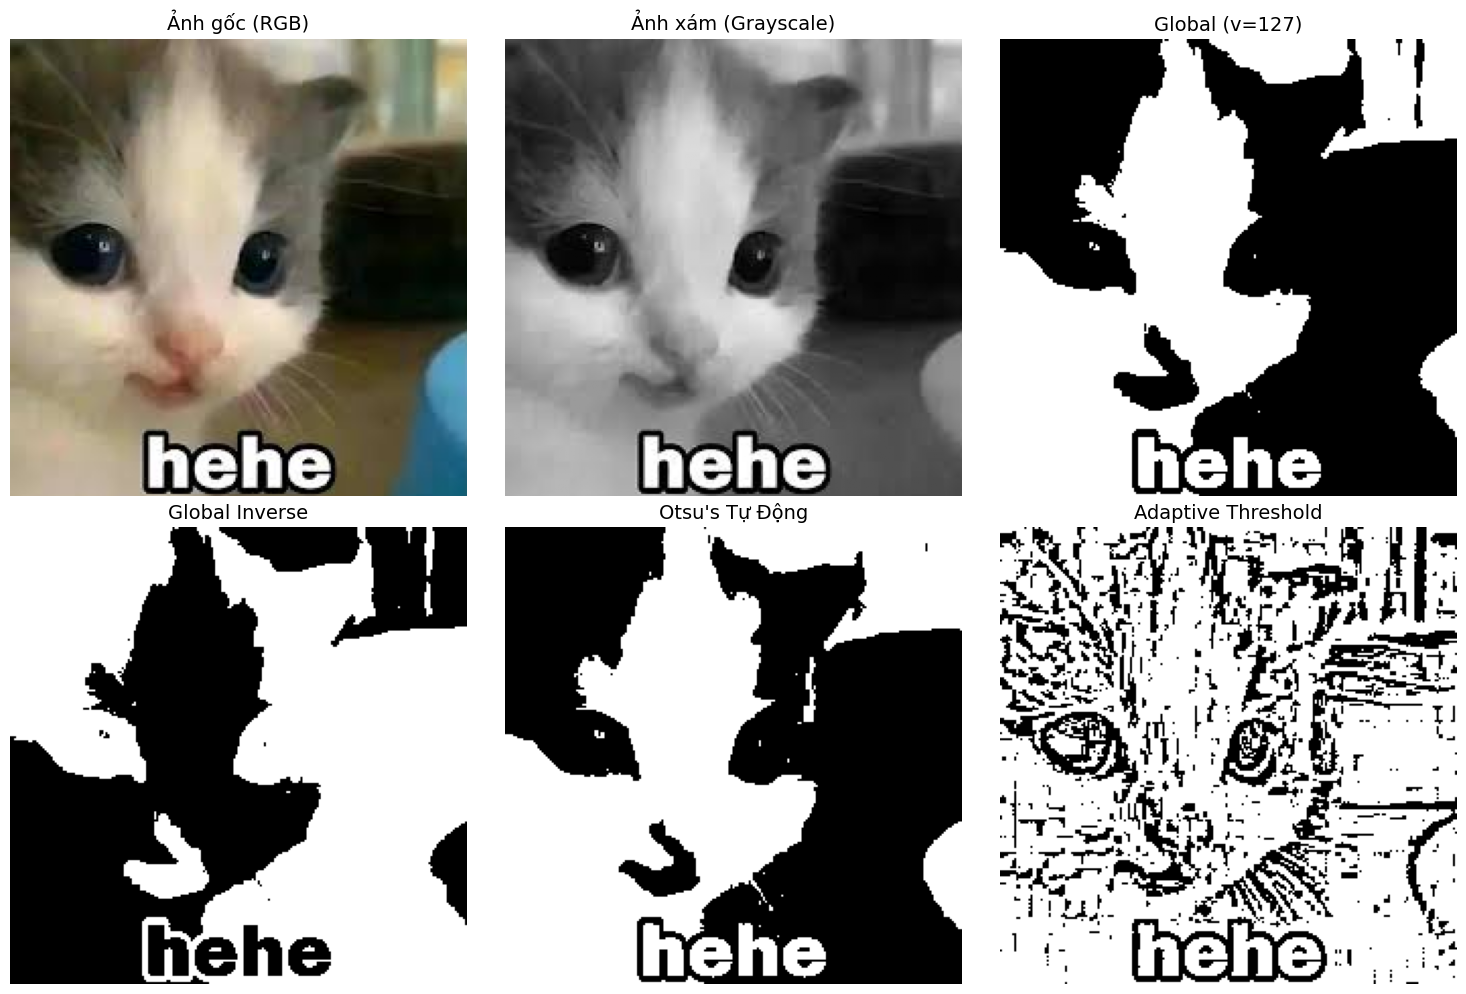

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh và xử lý màu sắc
# Đọc ảnh gốc (OpenCV đọc mặc định định dạng BGR)
img = cv2.imread('cat.jpg')

# Nếu không tìm thấy ảnh, báo lỗi
if img is None:
    print("Không tìm thấy file 'cat.jpg'. Hãy kiểm tra lại đường dẫn.")
else:
    # Chuyển đổi sang hệ màu RGB để hiển thị đúng màu gốc khi dùng matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Chuyển đổi ảnh sang ảnh xám (Grayscale)
    # RẤT QUAN TRỌNG: Thresholding chủ yếu tính toán trên ảnh 1 kênh màu (ảnh xám)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Áp dụng các phương pháp phân đoạn ảnh (Thresholding)

    # Phân đoạn 2.1: Global Thresholding - Cơ bản
    # Cài đặt cố định ngưỡng phân chia là 127. 
    # Điểm ảnh > 127 sẽ thành 255 (trắng), ngược lại thành 0 (đen).
    _, thresh_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Phân đoạn 2.2: Global Thresholding (Đảo ngược)
    _, thresh_global_inv = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    # Phân đoạn 2.3: Otsu's Thresholding
    # Tự động tìm ngưỡng tối ưu thay vì phải chọn số 127 thủ công
    # Thường cho kết quả tốt trên ảnh có bimodal histogram (biểu đồ cường độ sáng có 2 đỉnh phân biệt)
    _, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Phân đoạn 2.4: Adaptive Thresholding (Ngưỡng thích nghi)
    # Tự động tính các giá trị ngưỡng cho từng mảng vùng nhỏ của ảnh.
    # Cực kỳ hữu dụng khi ảnh có ánh sáng phản chiếu hoặc đổ bóng không đồng đều
    thresh_adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                            cv2.THRESH_BINARY, 11, 2)

    # 3. Trực quan hóa kết quả để so sánh
    titles = ['Ảnh gốc (RGB)', 'Ảnh xám (Grayscale)', 
              'Global (v=127)', 'Global Inverse', 
              "Otsu's Tự Động", 'Adaptive Threshold']
    
    images = [img_rgb, gray, thresh_global, thresh_global_inv, thresh_otsu, thresh_adaptive]

    plt.figure(figsize=(15, 10))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        # Ảnh gốc hiển thị màu, các ảnh còn lại dùng cmap='gray' (trắng đen)
        if i == 0:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap='gray')
            
        plt.title(titles[i], fontsize=14)
        plt.axis('off') # Ẩn đi các trục tọa độ cho rõ ảnh

    plt.tight_layout()
    plt.show()


Ngưỡng Otsu tự động tìm được là: 116.0


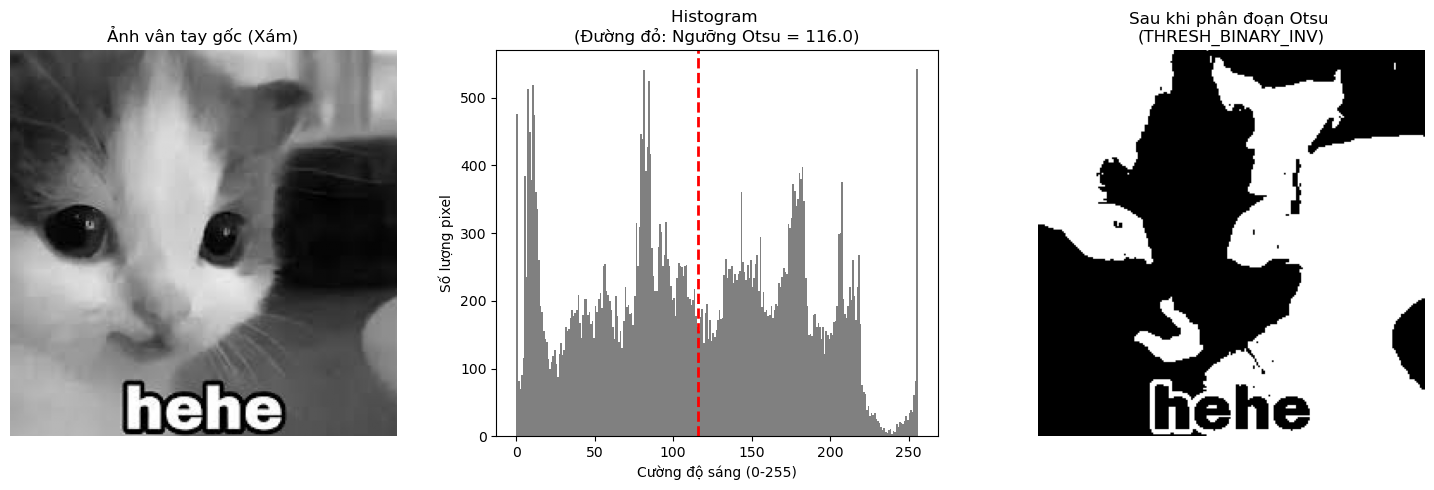

In [3]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh vân tay bằng định dạng ảnh xám (Grayscale)
# Thay 'vantay.jpg' bằng tên file ảnh thực tế của bạn
img_path = 'cat.jpg' 
fingerprint_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if fingerprint_gray is None:
    print(f"Không tìm thấy file '{img_path}'. Vui lòng dán đúng tên file ảnh giả định!")
else:
    # 2. Áp dụng thuật toán Otsu
    # Ta dùng THRESH_BINARY_INV vì vân tay thường có màu đen trên nền trắng,
    # việc đảo ngược (INV) sẽ giúp vân tay đổi thành màu trắng trên nền đen (dễ xử lý và làm nổi bật vân tay hơn).
    otsu_threshold, thresh_otsu = cv2.threshold(fingerprint_gray, 0, 255, 
                                                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    print(f"Ngưỡng Otsu tự động tìm được là: {otsu_threshold}")

    # 3. Trực quan hóa
    plt.figure(figsize=(15, 5))

    # 3.1 Ảnh vân tay gốc
    plt.subplot(1, 3, 1)
    plt.imshow(fingerprint_gray, cmap='gray')
    plt.title('Ảnh vân tay gốc (Xám)')
    plt.axis('off')

    # 3.2 Biểu đồ Histogram & đường vạch thể hiện ngưỡng Otsu
    plt.subplot(1, 3, 2)
    # Hàm ravel() giúp làm phẳng ma trận ảnh 2D thành mảng 1D để vẽ histogram
    plt.hist(fingerprint_gray.ravel(), bins=256, range=[0, 256], color='gray')
    plt.axvline(x=otsu_threshold, color='red', linestyle='dashed', linewidth=2)
    plt.title(f'Histogram \n(Đường đỏ: Ngưỡng Otsu = {otsu_threshold})')
    plt.xlabel('Cường độ sáng (0-255)')
    plt.ylabel('Số lượng pixel')

    # 3.3 Ảnh sau khi Threshold (Vân tay đã phân đoạn)
    plt.subplot(1, 3, 3)
    plt.imshow(thresh_otsu, cmap='gray')
    plt.title('Sau khi phân đoạn Otsu \n(THRESH_BINARY_INV)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


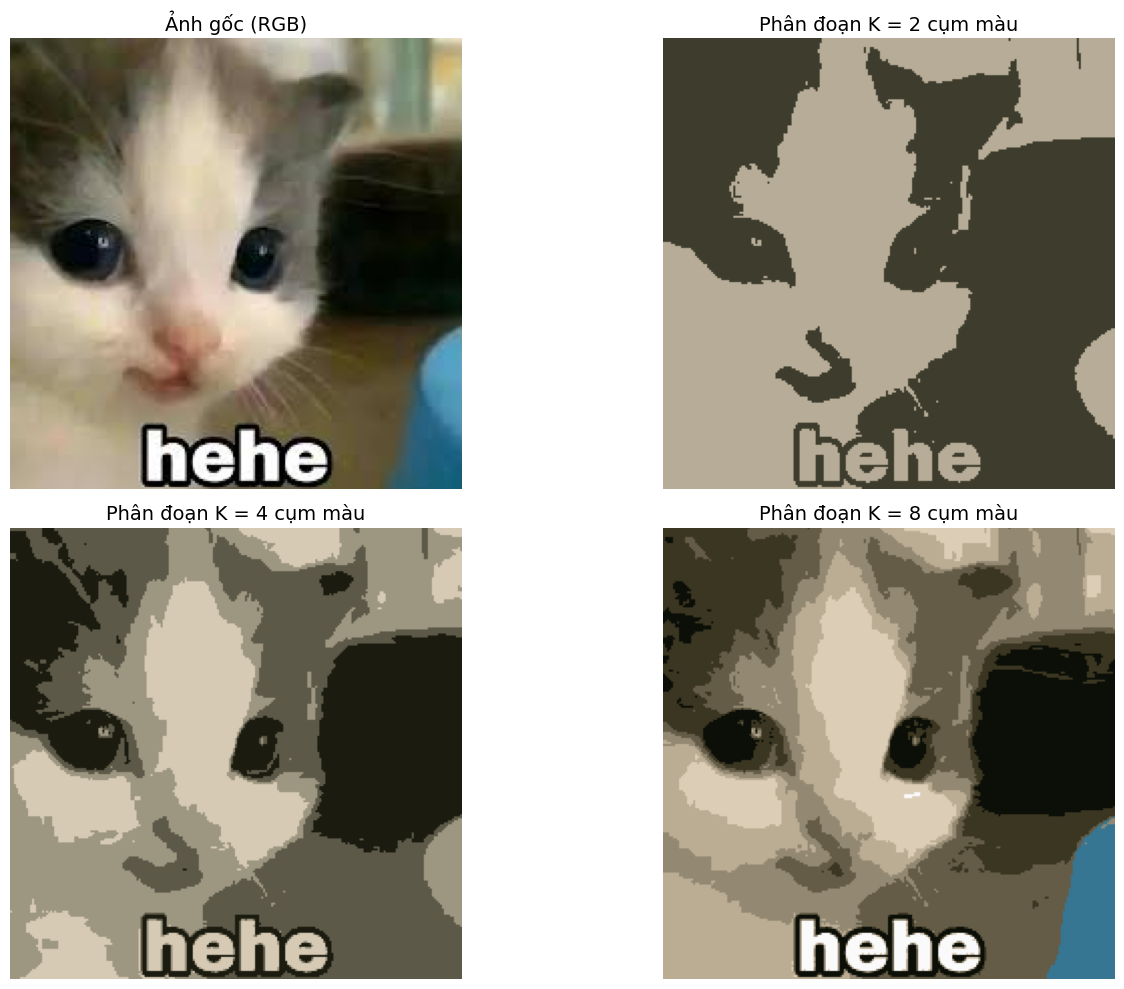

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc và chuyển đổi hệ màu
img = cv2.imread('cat.jpg')
if img is None:
    print("Vui lòng đảm bảo ảnh 'cat.jpg' nằm trong cùng thư mục.")
else:
    # Chuyển từ BGR (mặc định của OpenCV) sang RGB để hiển thị đúng màu
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Tiền xử lý ảnh cho thuật toán K-Means
    # Kích thước ảnh gốc là (H, W, 3). Ta cần làm phẳng (reshape) nó thành mảng 2 chiều 
    # với kích thước: (Tổng số Điểm Ảnh, 3 kênh màu RGB)
    pixel_values = img_rgb.reshape((-1, 3))
    
    # OpenCV yêu cầu dữ liệu phải ở định dạng số thực (float32) để tính trung bình cụm
    pixel_values = np.float32(pixel_values)

    # 3. Thiết lập tiêu chuẩn dừng (Criteria) cho thuật toán
    # Dừng thuật toán khi đã chạy đủ 100 vòng lặp (MAX_ITER) HOẶC 
    # độ xê dịch của các tâm điểm nhỏ hơn epsilon = 0.2 (EPS).
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    attempts = 10 # Số lần thuật toán chạy với các tâm khởi tạo ngẫu nhiên khác nhau

    # Chọn các giá trị K khác nhau để phân đoạn
    k_values = [2, 4, 8]
    segmented_images = []

    # 4. Chạy K-Means
    for k in k_values:
        # cv2.kmeans trả về: Độ lệch (ret), Nhãn của từng pixel (labels), Tâm của cụm (centers)
        ret, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 
                                          attempts, cv2.KMEANS_RANDOM_CENTERS)
        
        # Ép kiểu tâm cụm (chứa giá trị số thực) về lại số nguyên uint8 (0-255 màu pixel)
        centers = np.uint8(centers)
        
        # Nhúng (map) các màu của tâm cụm ngược lại vào các điểm ảnh gốc dựa theo "nhãn"
        segmented_data = centers[labels.flatten()]
        
        # Khôi phục mảng 1 chiều trở lại kích thước ma trận ảnh gốc (H, W, 3)
        segmented_image = segmented_data.reshape((img_rgb.shape))
        segmented_images.append(segmented_image)

    # 5. Trực quan hóa kết quả bằng Matplotlib
    plt.figure(figsize=(15, 10))

    # Vẽ ảnh gốc
    plt.subplot(2, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Ảnh gốc (RGB)', fontsize=14)
    plt.axis('off')

    # Vẽ các ảnh đã áp dụng K-Means theo các giá trị K
    for i, k in enumerate(k_values):
        plt.subplot(2, 2, i + 2)
        plt.imshow(segmented_images[i])
        plt.title(f'Phân đoạn K = {k} cụm màu', fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


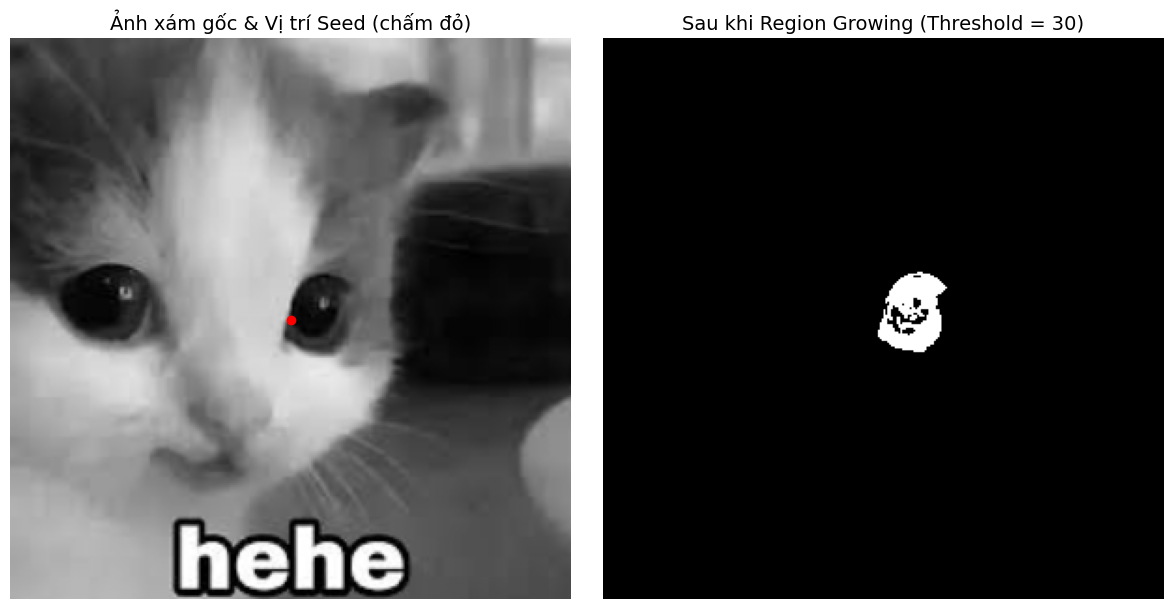

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(img, seed_pt, threshold=15):
    """
    Hàm phân đoạn ảnh bằng Region Growing.
    :param img: Ảnh đầu vào dạng xám (grayscale) 2D
    :param seed_pt: Tọa độ điểm mồi (x, y)
    :param threshold: Ngưỡng chênh lệch sáng tối đa để gộp vào vùng
    :return: Ảnh nhị phân sau khi phân đoạn (255: Thuộc vùng, 0: Nền)
    """
    # Lấy kích thước ảnh
    h, w = img.shape
    
    # Tạo mask nhị phân (ảnh kết quả)
    segmented = np.zeros_like(img)
    
    # Ma trận đánh dấu các điểm đã thăm, tránh bị lặp lại vô tận
    visited = np.zeros_like(img, dtype=bool)
    
    # Hàng đợi (Queue) dùng để duyệt các điểm loang theo logic BFS
    queue = [seed_pt]
    
    # Tọa độ x, y của điểm seed
    sx, sy = seed_pt
    seed_val = int(img[sy, sx]) # Cường độ sáng tại điểm mồi
    
    # Đánh dấu điểm mồi là "Đã thuộc vùng" và "Đã thăm"
    segmented[sy, sx] = 255
    visited[sy, sx] = True
    
    # 8 hướng di chuyển (Trên, Dưới, Trái, Phải và 4 đường chéo)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), 
                  (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    # Duyệt giống kiểu thuật toán "Đổ màu" (Flood Fill) trên MS Paint
    while queue:
        # Lấy một pixel ra khỏi hàng đợi
        cx, cy = queue.pop(0)
        
        # Kiểm tra 8 điểm ảnh xung quanh nó
        for dx, dy in directions:
            nx, ny = cx + dx, cy + dy
            
            # Kiểm tra pixel lân cận có nằm trong phạm vi ảnh và chưa được xét không?
            if 0 <= nx < w and 0 <= ny < h and not visited[ny, nx]:
                # Tính lượng chênh lệch độ sáng
                curr_val = int(img[ny, nx])
                
                # Nếu khoảng cách độ sáng với mốc ban đầu nhỏ hơn hoặc bằng ngưỡng
                if abs(curr_val - seed_val) <= threshold:
                    segmented[ny, nx] = 255  # Gộp vào vùng
                    queue.append((nx, ny))    # Đưa vào hàng đợi để đi loang tiếp
                
                # Đánh dấu bước qua là đã xét
                visited[ny, nx] = True

    return segmented

# 1. Đọc ở định dạng ảnh xám
img = cv2.imread('cat.jpg', 0)

if img is None:
    print("Vui lòng đảm bảo ảnh 'cat.jpg' nằm trong cùng thư mục.")
else:
    # Resize lại cho nhỏ bớt để thuật toán Python chạy loang nhanh hơn (cố định chiều ngang 300px)
    ratio = 300.0 / img.shape[1]
    dim = (300, int(img.shape[0] * ratio))
    img_resized = cv2.resize(img, dim)

    # 2. Bắt đầu với điểm mồi ở chính giữa tấm ảnh
    # (Tọa độ OpenCV là (x, y) - Ngang, Dọc)
    seed_point = (img_resized.shape[1] // 2, img_resized.shape[0] // 2)

    # 3. Chạy Hàm Region Growing
    # Ngưỡng phân tách Tolerance. 
    # Ví dụ: threshold = 30 tức là các màu chênh lệch +-30 sáng với khu vực Seed Point sẽ bị hút vào
    seg_img = region_growing(img_resized, seed_pt=seed_point, threshold=30)

    # 4. Trực quan hóa
    plt.figure(figsize=(12, 6))

    # Vẽ ảnh gốc lên mạng
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized, cmap='gray')
    # Chấm một điểm nhỏ màu đỏ lọt vào vị trí điểm mồi để dễ phân biệt
    plt.plot(seed_point[0], seed_point[1], 'ro', markersize=6)
    plt.title('Ảnh xám gốc & Vị trí Seed (chấm đỏ)', fontsize=14)
    plt.axis('off')

    # Vẽ ảnh Phân đoạn
    plt.subplot(1, 2, 2)
    plt.imshow(seg_img, cmap='gray')
    plt.title('Sau khi Region Growing (Threshold = 30)', fontsize=14)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


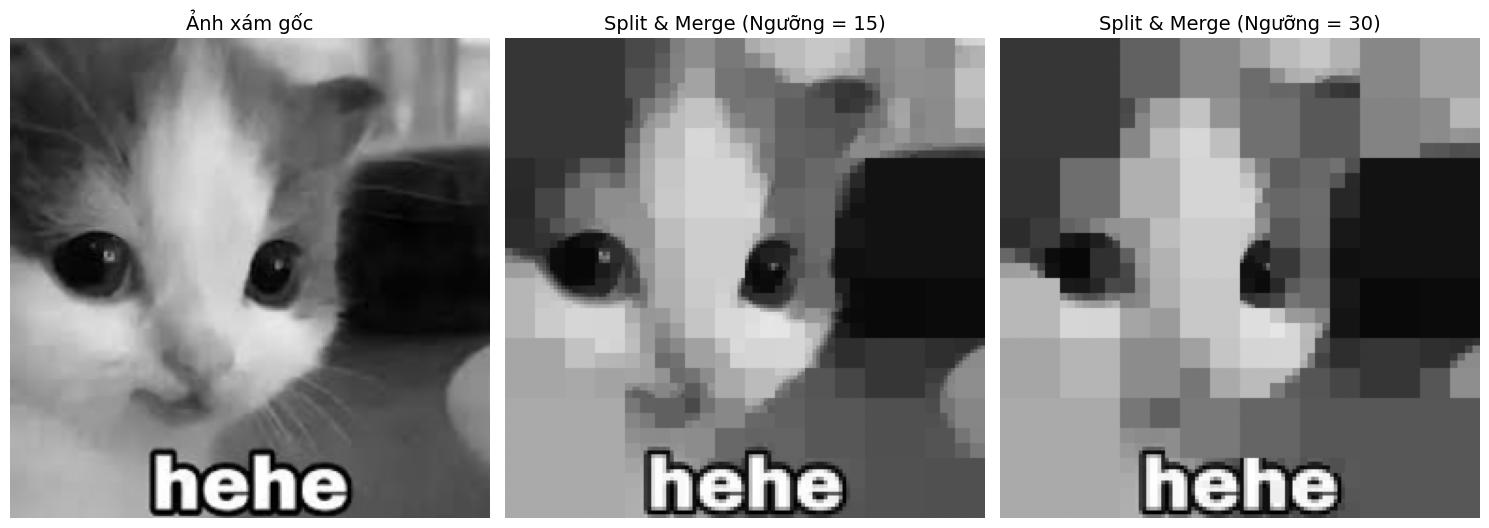

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def split_and_merge_simulation(img, threshold):
    """
    Mô phỏng đệ quy quá trình Split của thuật toán Split & Merge (Quad-Tree)
    :param img: Ảnh xám đầu vào
    :param threshold: Ngưỡng lệch chuẩn. Độ lệch càng thấp, ảnh càng bị băm nhỏ.
    """
    # Khởi tạo một bức ảnh đen mới để chứa kết quả đầu ra
    res = np.zeros_like(img)
    
    def split(x, y, w, h):
        # 1. Trích xuất vùng ảnh con (Region of Interest)
        roi = img[y:y+h, x:x+w]
        
        # 2. Tính Trug Bình (Mean) và Độ lệch chuẩn (Standard Deviation)
        # Độ lệch chuẩn càng lớn => vùng ảnh đó chứa nhiều chi tiết tương phản
        mean_val, stddev = cv2.meanStdDev(roi)
        
        # 3. Kiểm tra điều kiện "Đồng nhất"
        # Nếu chỉ số dao động màu < ngưỡng (Tức là vùng đã khá đồng màu mượt mà)
        # HOẶC vùng quá nhỏ (1x1, 2x2) thì DỪNG CHIA, tô toàn bộ vùng bằng màu Trung Bình
        if stddev[0][0] < threshold or w <= 2 or h <= 2:
            res[y:y+h, x:x+w] = mean_val[0][0]
        else:
            # 4. Nếu vùng CHƯA đồng nhất => Chia vùng hiện tại làm 4 phần vuông bằng nhau
            w1, w2 = w // 2, w - w // 2
            h1, h2 = h // 2, h - h // 2
            
            # GỌI ĐỆ QUY chẻ 4 hướng tiếp theo (Góc trái/phải - Trên/dưới)
            split(x, y, w1, h1)               # Top - Left
            split(x + w1, y, w2, h1)          # Top - Right
            split(x, y + h1, w1, h2)          # Bottom - Left
            split(x + w1, y + h1, w2, h2)     # Bottom - Right

    # Bắt đầu gọi hàm đệ quy từ tọa độ (0,0) bao trọn toàn bộ ảnh
    split(0, 0, img.shape[1], img.shape[0])
    return res

# --- CHẠY THỬ NGHIỆM ---

# 1. Tải ảnh xám
img = cv2.imread('cat.jpg', 0)

if img is None:
    print("Vui lòng đảm bảo file 'cat.jpg' nằm trong cùng thư mục.")
else:
    # Scale ảnh nhỏ lại để chạy Quad-tree đệ quy siêu nhanh (hạn chế tràn RAM)
    # Vì đệ quy bằng Python khá nặng nề
    img_resized = cv2.resize(img, (256, int(256 * img.shape[0] / img.shape[1])))

    # 2. Gọi logic Split (Mô phỏng) cắt gọt cây tứ phân với 2 ngưỡng khác nhau
    # Ngưỡng thấp (Khéo léo phân tách cả những chi tiết nhỏ gọn)
    split_low_threshold = split_and_merge_simulation(img_resized, threshold=15)
    
    # Ngưỡng cao (Dễ dãi, làm mờ đi các chi tiết, tạo ra các ô vuông to)
    split_high_threshold = split_and_merge_simulation(img_resized, threshold=30)

    # 3. Trực quan hóa
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title('Ảnh xám gốc', fontsize=14)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(split_low_threshold, cmap='gray')
    plt.title('Split & Merge (Ngưỡng = 15)', fontsize=14)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(split_high_threshold, cmap='gray')
    plt.title('Split & Merge (Ngưỡng = 30)', fontsize=14)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


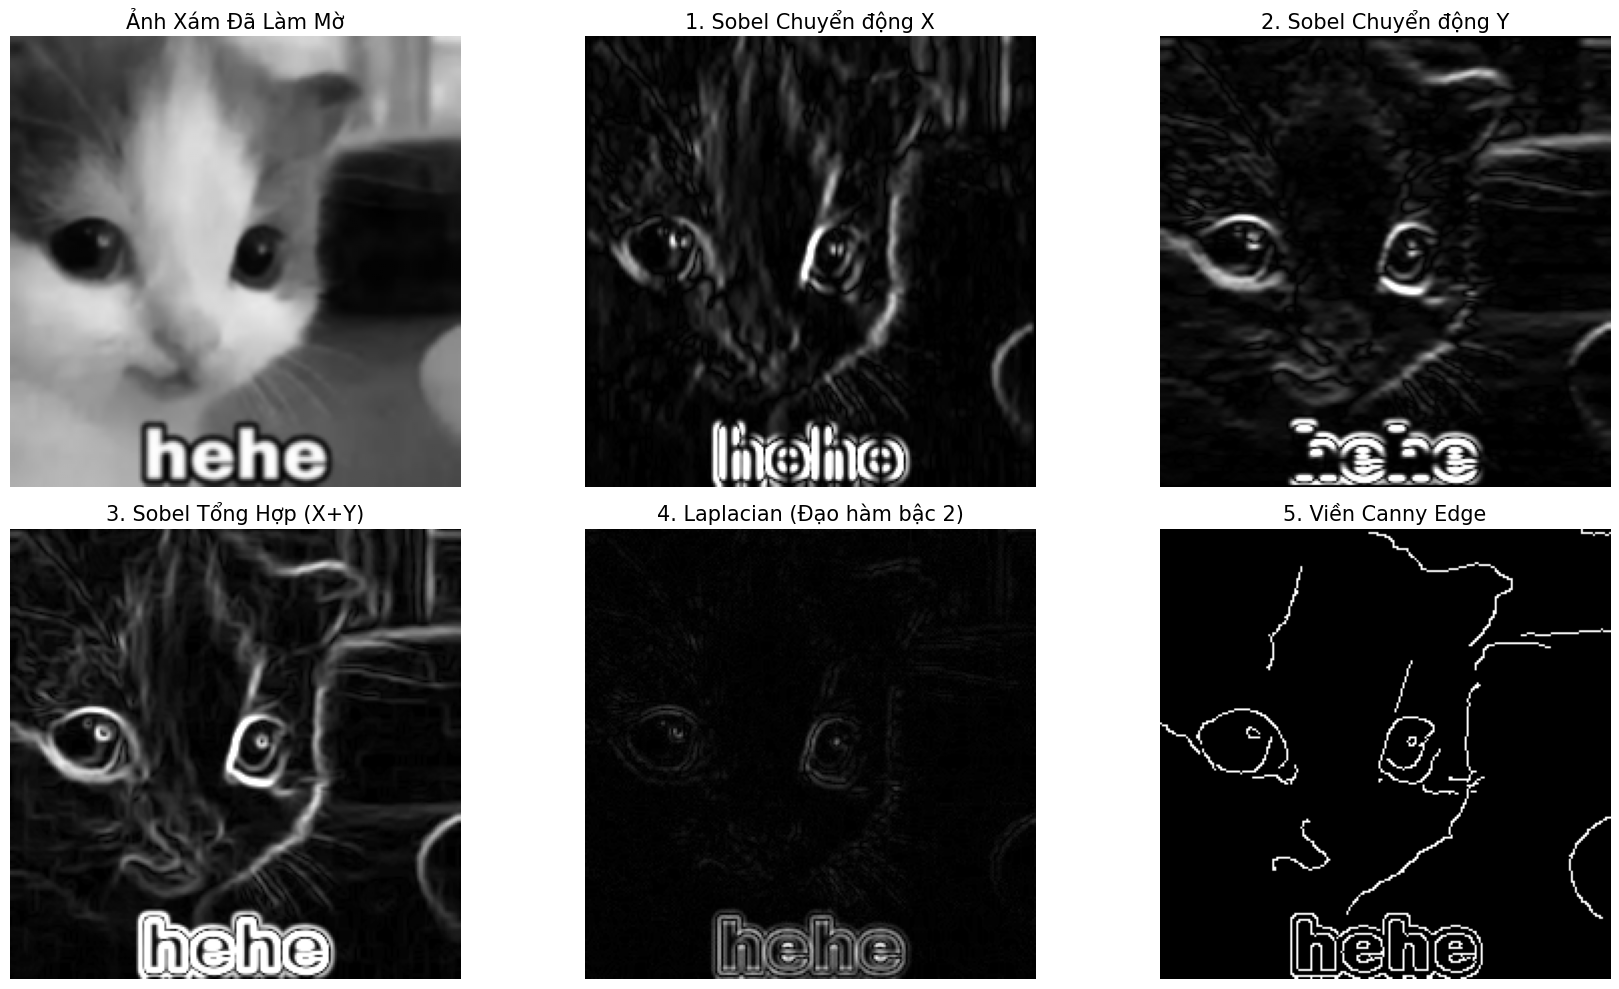

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chỉ dùng kênh xám (Grayscale)
img = cv2.imread('cat.jpg')

if img is None:
    print("Vui lòng đảm bảo file 'cat.jpg' nằm trong cùng thư mục.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Xóa Nhiễu (Noise Removal) - BƯỚC CỰC KỲ QUAN TRỌNG
    # Việc tìm viền rất nhạy cảm với các hạt nhiễu sạn trên ảnh. 
    # Bắt buộc phải làm mờ (Blur) ảnh trước khi tìm cạnh để đường viền không bị vỡ/nát.
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # =======================================================
    # PHƯƠNG PHÁP 1: BỘ LỌC SOBEL (Tính đạo hàm bậc 1)
    # =======================================================
    # Sobel X phát hiện các đường viền dọc (do đạo hàm theo chiều x)
    # Sobel Y phát hiện các đường viền ngang (do đạo hàm theo chiều y)
    # cv2.CV_64F giúp giữ lại các giá trị đạo hàm âm trước khi tính độ lớn (Magnitude)
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    # Gộp 2 hướng X, Y lại để ra đường biên hoàn chỉnh
    sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)
    
    # Ép kiểu dữ liệu về lại 0-255 để có thể hiển thị ảnh
    sobel_x = cv2.convertScaleAbs(sobel_x)
    sobel_y = cv2.convertScaleAbs(sobel_y)
    sobel_magnitude = cv2.convertScaleAbs(sobel_magnitude)

    # =======================================================
    # PHƯƠNG PHÁP 2: BỘ LỌC LAPLACIAN (Tính đạo hàm bậc 2)
    # =======================================================
    # Phát hiện mọi sự chuyển đổi sáng/tối quanh 1 mảnh pixel theo mọi hướng
    laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
    laplacian = cv2.convertScaleAbs(laplacian)

    # =======================================================
    # PHƯƠNG PHÁP 3: THUẬT TOÁN CANNY EDGE DETECTION (Khuyên dùng)
    # =======================================================
    # Canny xịn hơn vì nó kết hợp cả Noise Filter + Hysteresis (Ngưỡng kép) 
    # và xóa các nét đôi (chỉ giữ lại 1 nét viền mỏng nhất - Non-maximum suppression)
    # Thông số 50: Ngưỡng thấp (Bỏ qua viền yếu) | 150: Ngưỡng cao (Viền mạnh chắc chắn hiển thị)
    canny = cv2.Canny(blurred, 50, 150)

    # 3. Trực quan hóa So sánh toàn diện
    plt.figure(figsize=(18, 10))

    titles = ['Ảnh Xám Đã Làm Mờ', '1. Sobel Chuyển động X', '2. Sobel Chuyển động Y', 
              '3. Sobel Tổng Hợp (X+Y)', '4. Laplacian (Đạo hàm bậc 2)', '5. Viền Canny Edge']
    
    images = [blurred, sobel_x, sobel_y, sobel_magnitude, laplacian, canny]

    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i], fontsize=15)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
